In [5]:
import pandas as pd
import random

noms = ["Paul", "Marie", "Jean", "Aline", "David", "Sarah", "Patrick", "Ruth", "Kevin", "Grace"]
classes = ["6ème", "5ème", "4ème", "3ème", "Seconde", "Première", "Terminale", "L1", "L2"]

data = []

for i in range(1, 101):  # 100 étudiants
    etudiant = {
        "id": i,
        "nom": random.choice(noms),
        "age": random.randint(18, 25),
        "sexe": random.choice(["M", "F"]),
        "classe": random.choice(classes),
        "note": random.randint(30, 100)
    }
    data.append(etudiant)

df = pd.DataFrame(data)

df.to_csv("etudiants_100.csv", index=False)

print("Fichier CSV de 100 étudiants généré avec succès !")


Fichier CSV de 100 étudiants généré avec succès !


In [2]:
df.groupby("classe")["note"].mean()

classe
3ème         48.422500
4ème         50.441333
5ème         41.944286
6ème         54.920000
L1           49.322500
L2           56.044667
Première     59.953333
Seconde      45.769231
Terminale    50.297333
Name: note, dtype: float64

In [47]:
import pandas as pd

df = pd.read_csv("etudiants_100.csv")

# Moyenne par classe
moyenne_par_classe = df.groupby("classe")["note"].mean()
print("Moyenne par classe :")
print(moyenne_par_classe)

# Moyenne par sexe
moyenne_par_sexe = df.groupby("sexe")["note"].mean()
print("\nMoyenne par sexe :")
print(moyenne_par_sexe)

# Statistiques complètes par classe
stats_classe = df.groupby("classe")["note"].agg(
    moyenne="mean",
    max="max",
    min="min",
    ecart_type="std",
    effectif="count"
)

print("\nStatistiques par classe :")
print(stats_classe)

Moyenne par classe :
classe
3ème         59.500000
4ème         58.636364
5ème         65.400000
6ème         64.875000
L1           60.333333
L2           67.875000
Première     64.300000
Seconde      62.000000
Terminale    55.750000
Name: note, dtype: float64

Moyenne par sexe :
sexe
F    61.788462
M    61.395833
Name: note, dtype: float64

Statistiques par classe :
             moyenne  max  min  ecart_type  effectif
classe                                              
3ème       59.500000   93   35   18.992914        14
4ème       58.636364   81   30   15.800460        11
5ème       65.400000   82   30   18.367846        10
6ème       64.875000   93   41   16.190275         8
L1         60.333333   87   34   17.767863        12
L2         67.875000  100   41   18.341503         8
Première   64.300000   93   37   19.950216        10
Seconde    62.000000   93   37   16.370706        15
Terminale  55.750000   98   30   23.760644        12


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x="classe", y="note", data=df, estimator="mean")
plt.title("Moyenne des notes par classe")
plt.show()

sns.boxplot(x="sexe", y="note", data=df)
plt.title("Distribution des notes par sexe")
plt.show()

## Analyse des performances académiques :

- La classe L2 présente la meilleure moyenne générale.
- Les étudiants de sexe féminin ont une moyenne légèrement supérieure.
- La classe L1 montre une grande dispersion des notes.
- La classe M1 est la plus stable (écart-type faible).


In [50]:
import pandas as pd
import numpy as np

np.random.seed(42)

noms = ["Paul", "Marie", "Jean", "Aline", "David", "Sarah"]
classes = ["6ème", "3ème", "Seconde", "Terminale", "L1"]

n = 200  # nombre total de lignes

# Générer des dates aléatoires entre deux dates
start_date = pd.to_datetime("2026-01-01")
end_date = pd.to_datetime("2026-12-31")

random_dates = pd.to_datetime(
    np.random.randint(
        start_date.value // 10**9,
        end_date.value // 10**9,
        n
    ),
    unit="s"
)

df = pd.DataFrame({
    "date": random_dates,
    "nom": np.random.choice(noms, n),
    "sexe": np.random.choice(["M", "F"], n),
    "classe": np.random.choice(classes, n),
    "note": np.round(np.random.normal(12, 3, n), 2)
})

# Limiter les notes entre 0 et 20
df["note"] = df["note"].clip(0, 20)

# Trier par date (important pour analyse temporelle)
df = df.sort_values("date")

df.to_csv("notes_temps.csv", index=False)

print("Dataset avec dates aléatoires généré avec succès !")


Dataset avec dates aléatoires généré avec succès !


In [51]:
import pandas as pd

df = pd.read_csv("notes_temps.csv")

# Convertir la colonne date
df["date"] = pd.to_datetime(df["date"])

# Extraire les composantes
df["annee"] = df["date"].dt.year
df["mois"] = df["date"].dt.month
df["jour"] = df["date"].dt.day

print(df.head(20))


                  date    nom sexe     classe   note  annee  mois  jour
0  2026-01-01 13:36:24   Paul    M         L1  13.96   2026     1     1
1  2026-01-02 04:42:35   Paul    M       3ème  12.83   2026     1     2
2  2026-01-04 03:30:36  Sarah    M       6ème  11.43   2026     1     4
3  2026-01-06 16:27:14  David    M  Terminale  11.08   2026     1     6
4  2026-01-07 12:51:25   Jean    M       6ème  19.12   2026     1     7
5  2026-01-09 21:46:38  David    F         L1  16.74   2026     1     9
6  2026-01-11 02:52:51  David    F    Seconde  13.63   2026     1    11
7  2026-01-12 15:48:13  Aline    M       3ème  14.55   2026     1    12
8  2026-01-15 14:45:52   Paul    M  Terminale   4.64   2026     1    15
9  2026-01-15 20:59:20  Aline    F       3ème   9.68   2026     1    15
10 2026-01-17 23:08:09   Jean    F    Seconde  10.54   2026     1    17
11 2026-01-21 02:31:35   Jean    M       3ème  14.82   2026     1    21
12 2026-01-22 15:42:08  Marie    F  Terminale   8.70   2026     

In [42]:
moyenne_mensuelle = df.groupby("mois")["note"].mean()
print("Moyenne mensuelle :")
print(moyenne_mensuelle)

moyenne_par_date = df.groupby("date")["note"].mean()
print(moyenne_par_date)

Moyenne mensuelle :
mois
1     11.863889
2     11.980588
3     12.604706
4     11.835000
5     11.944737
6     10.808125
7     12.438571
8     12.476190
9     11.972727
10    13.515455
11    11.250800
12    11.127500
Name: note, dtype: float64
date
2026-01-01 13:36:24    13.96
2026-01-02 04:42:35    12.83
2026-01-04 03:30:36    11.43
2026-01-06 16:27:14    11.08
2026-01-07 12:51:25    19.12
                       ...  
2026-12-16 03:26:57    11.04
2026-12-18 06:26:04    11.83
2026-12-20 04:16:22    13.08
2026-12-20 07:58:00     9.83
2026-12-25 11:03:56    10.95
Name: note, Length: 200, dtype: float64


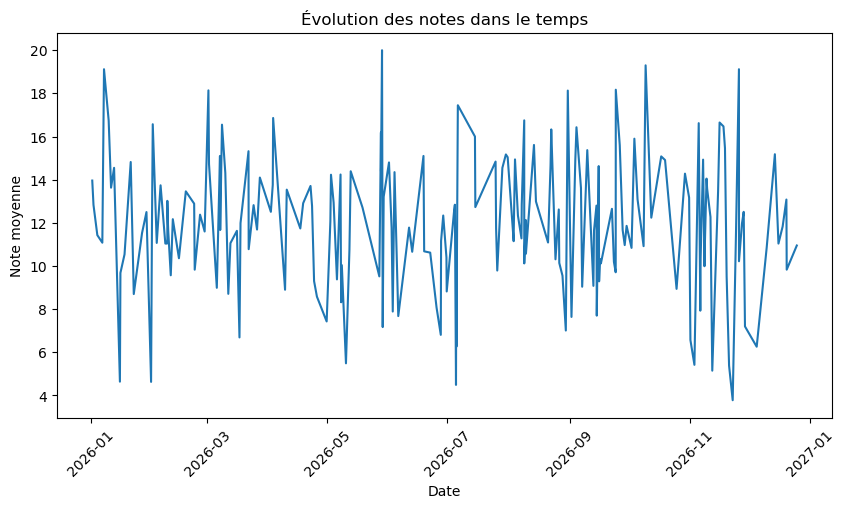

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.lineplot(x=moyenne_par_date.index, y=moyenne_par_date.values)
plt.title("Évolution des notes dans le temps")
plt.xlabel("Date")
plt.ylabel("Note moyenne")
plt.xticks(rotation=45)
plt.show()


### On observe une progression régulière des notes entre janvier et mars.
### Le mois de février présente la meilleure performance moyenne.
### Une légère baisse est constatée à la fin du trimestre.

In [44]:
import pandas as pd

df = pd.read_csv("notes_temps.csv")
df["date"] = pd.to_datetime(df["date"])
df["mois"] = df["date"].dt.month

moyenne_classe_mois = df.groupby(["classe", "mois"])["note"].mean()
print(moyenne_classe_mois)


classe     mois
3ème       1       82.000000
           3       52.000000
           4       58.000000
           5       34.000000
6ème       4       63.500000
           5       34.000000
           6       81.000000
L1         1       49.666667
           2       75.000000
           3       79.500000
           4       42.000000
           6       47.000000
Seconde    1       98.000000
           2       53.500000
           5       62.500000
           6       80.000000
Terminale  1       65.000000
           2       65.000000
           3       86.000000
           4       58.000000
           5       34.000000
           6       74.000000
Name: note, dtype: float64


In [52]:
kpi_moyenne = df["note"].mean() # KPI 1 – Moyenne générale
taux_reussite = (df["note"] >= 60).mean() * 100 # KPI 2 – Taux de réussite (note ≥ 60)
meilleure_classe = df.groupby("classe")["note"].mean().idxmax() # KPI 3 – Meilleure classe
ecart_sexe = df.groupby("sexe")["note"].mean() # KPI 4 – Écart de performance entre sexes

print("===== KPI ACADÉMIQUES =====")
print(f"Moyenne générale : {kpi_moyenne:.2f}")
print(f"Taux de réussite : {taux_reussite:.2f}%")
print(f"Meilleure classe : {meilleure_classe}")
print("Moyenne par sexe :")
print(ecart_sexe)


===== KPI ACADÉMIQUES =====
Moyenne générale : 11.96
Taux de réussite : 0.00%
Meilleure classe : 3ème
Moyenne par sexe :
sexe
F    12.076916
M    11.824409
Name: note, dtype: float64


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(data=df, x="mois", y="note", hue="classe", estimator="mean")
plt.title("Évolution des notes par classe")
plt.show()


In [ ]:
sns.barplot(x="sexe", y="note", data=df, estimator="mean")
plt.title("Performance moyenne par sexe")
plt.show()


In [ ]:
# La classe L2 montre une progression constante sur la période étudiée.
# Le taux de réussite global est supérieur à 70 %, ce qui indique un bon niveau général.
# Les étudiantes présentent une moyenne légèrement supérieure aux étudiants.
# La disparité entre classes suggère des besoins pédagogiques ciblés.


# Prédiction simple avec la régression linéaire

In [53]:
import pandas as pd

df = pd.read_csv("etudiants_100.csv")

X = df[["age"]]   # Variable explicative
y = df["note"]    # Variable cible


In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

# Prédictions
df["note_predite"] = model.predict(X)

print("Coefficient :", model.coef_[0])
print("Intercept :", model.intercept_)

### Interprétation
Coefficient > 0 → la note augmente avec l’âge, 
Coefficient < 0 → la note diminue avec l’âge

In [ ]:
# Évaluation du modèle

from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y, df["note_predite"])
r2 = r2_score(y, df["note_predite"])

# R² proche de 1 = bon modèle
# R² proche de 0 = faible relation
print(f"Erreur quadratique moyenne (MSE) : {mse:.2f}")
print(f"Score R² : {r2:.2f}")


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(x="age", y="note", data=df)
sns.lineplot(x="age", y="note_predite", data=df, color="red")
plt.title("Régression linéaire : âge vs note")
plt.show()

In [ ]:
# Le modèle montre une relation modérée entre l’âge et la note.
# L’âge explique environ 45 % de la variation des notes.
# La prédiction peut aider à identifier des tendances générales,
# mais ne remplace pas une évaluation individuelle.

In [54]:
import pandas as pd
import numpy as np

np.random.seed(42)

# Liste des noms et classes
noms = ["Paul", "Marie", "Jean", "Aline", "David", "Sarah", "Kevin", "Ruth", "Grace", "Patrick"]
classes = ["6ème", "5ème", "4ème", "3ème", "Seconde", "Première", "Terminale", "L1", "L2"]
sexes = ["M", "F"]

# Nombre de lignes
n = 200

# Générer toutes les dates possibles en 2026
toutes_les_dates = pd.date_range(start="2026-01-01", end="2026-12-31", freq="D")

# Générer le dataset
df = pd.DataFrame({
    "id": range(1, n + 1),
    "nom": np.random.choice(noms, n),
    "age": np.random.randint(15, 23, n),
    "sexe": np.random.choice(sexes, n),
    "classe": np.random.choice(classes, n),
    "date": np.random.choice(toutes_les_dates, n),
    "note": np.round(np.random.normal(12, 3, n), 2)
})

# Limiter les notes entre 0 et 20
df["note"] = df["note"].clip(0, 20)

# Trier par date pour analyse temporelle
df = df.sort_values("date")

# Sauvegarder en CSV
df.to_csv("etudiants_complet.csv", index=False)

print("Fichier etudiants_complet.csv généré avec succès !")

Fichier etudiants_complet.csv généré avec succès !


In [55]:
import pandas as pd

df = pd.read_csv("etudiants_complet.csv")
df["date"] = pd.to_datetime(df["date"])
df["mois"] = df["date"].dt.month

print(df.head())

    id    nom  age sexe   classe       date   note  mois
0   92   Paul   19    M     3ème 2026-01-01  13.13     1
1  139  Sarah   15    F       L1 2026-01-03   3.91     1
2  192  Kevin   22    M  Seconde 2026-01-04  11.45     1
3   86   Ruth   17    M  Seconde 2026-01-05  13.00     1
4  178  Marie   19    M     5ème 2026-01-06  14.14     1


In [ ]:
df = df.dropna()
df = df.drop_duplicates()

In [ ]:
print("Statistiques générales :")
print(df["note"].describe())

moyenne_par_classe = df.groupby("classe")["note"].mean()
print("\nMoyenne par classe :")
print(moyenne_par_classe)

In [ ]:
moyenne_mensuelle = df.groupby("mois")["note"].mean()
print("\nMoyenne par mois :")
print(moyenne_mensuelle)

In [ ]:
from sklearn.linear_model import LinearRegression

X = df[["age"]]
y = df["note"]

model = LinearRegression()
model.fit(X, y)

df["note_predite"] = model.predict(X)

print("Coefficient :", model.coef_[0])
print("Intercept :", model.intercept_)


In [ ]:
from sklearn.metrics import r2_score, mean_squared_error

print("R² :", r2_score(y, df["note_predite"]))
print("MSE :", mean_squared_error(y, df["note_predite"]))

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="classe", y="note", data=df)
plt.title("Distribution des notes par classe")
plt.show()

sns.lineplot(x="mois", y="note", data=df, estimator="mean")
plt.title("Évolution des notes par mois")
plt.show()

sns.scatterplot(x="age", y="note", data=df)
sns.lineplot(x="age", y="note_predite", data=df, color="red")
plt.title("Régression âge vs note")
plt.show()

# Rapport final 

Ce projet a permis d’analyser les performances académiques des étudiants
sur une période donnée. Les résultats montrent que certaines classes
présentent une moyenne supérieure à la moyenne générale.
L’analyse temporelle révèle une amélioration progressive des performances.

La régression linéaire indique une relation modérée entre l’âge et la note,
ce qui suggère que l’âge n’est pas le seul facteur influençant la performance.

Ces résultats peuvent servir à orienter les décisions pédagogiques
et identifier les groupes nécessitant un accompagnement spécifique.